In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Para que los gráficos salgan con un tamaño cómodo
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10


## 2. Descripción del conjunto de datos

Cargamos el Wine Dataset desde `scikit-learn`.
Este dataset contiene información química de vinos y una variable objetivo con **3 clases**.


In [2]:
# Cargar el dataset
wine = load_wine(as_frame=True)

# Separar variables predictoras y objetivo
X = wine.data
y = wine.target

# Unir en un solo DataFrame para explorar más fácil
df = wine.frame.copy()

print("Primeras filas del dataset:")
display(df.head())

print("Dimensiones del dataset:", df.shape)
print("Cantidad de clases:", len(np.unique(y)))
print("Nombres de las clases:", wine.target_names)


Primeras filas del dataset:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0


Dimensiones del dataset: (178, 14)
Cantidad de clases: 3
Nombres de las clases: ['class_0' 'class_1' 'class_2']


## 3. Exploración de los datos

Aquí revisamos:

- dimensiones del dataset
- tipos de variables
- valores faltantes
- estadísticas descriptivas
- distribución de clases


In [3]:
print("Información general del dataset:\n")
print(df.info())

print("\nValores faltantes por columna:")
print(df.isnull().sum())

print("\nEstadísticas descriptivas:")
display(df.describe())


Información general del dataset:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258,0.938202
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474,0.775035
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000,0.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000,0.000000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000,1.000000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000,2.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000,2.000000


Distribución de clases:
target
0    59
1    71
2    48
Name: count, dtype: int64


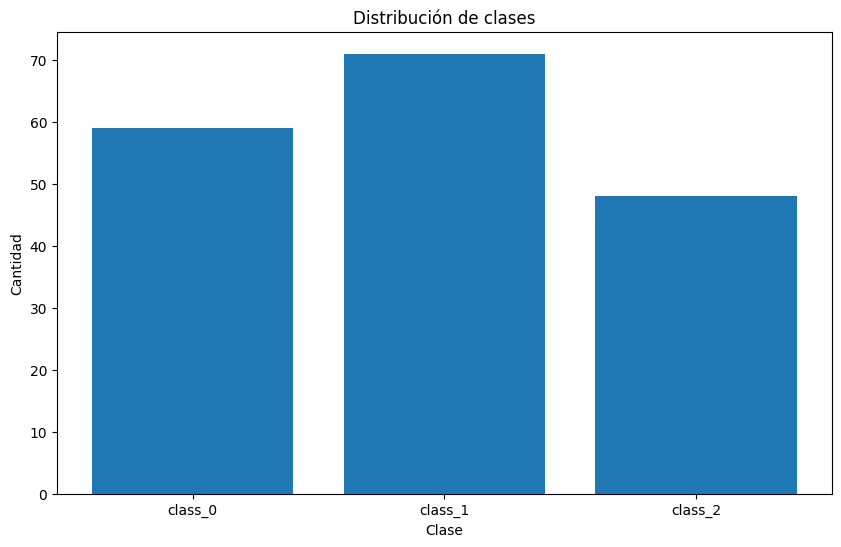

In [4]:
# Distribución de clases
conteo_clases = y.value_counts().sort_index()

print("Distribución de clases:")
print(conteo_clases)

plt.bar(wine.target_names, conteo_clases.values)
plt.title("Distribución de clases")
plt.xlabel("Clase")
plt.ylabel("Cantidad")
plt.show()



La distribución de clases no es perfectamente uniforme, pero tampoco está extremadamente desbalanceada.  
Eso ayuda a que la comparación entre LDA y QDA sea más limpia.


## 4. Visualización de los datos



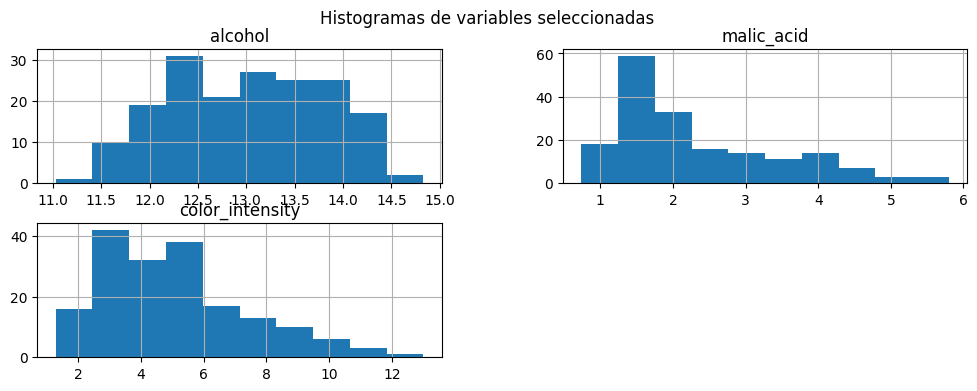

In [5]:
# Histograma de algunas variables
variables_hist = ["alcohol", "malic_acid", "color_intensity"]

df[variables_hist].hist(figsize=(12, 4))
plt.suptitle("Histogramas de variables seleccionadas")
plt.show()



Aquí se ve que varias variables no siguen exactamente la misma forma de distribución.
Eso es importante porque LDA y QDA parten de supuestos gaussianos por clase, y en la práctica esos supuestos rara vez se cumplen de forma perfecta.


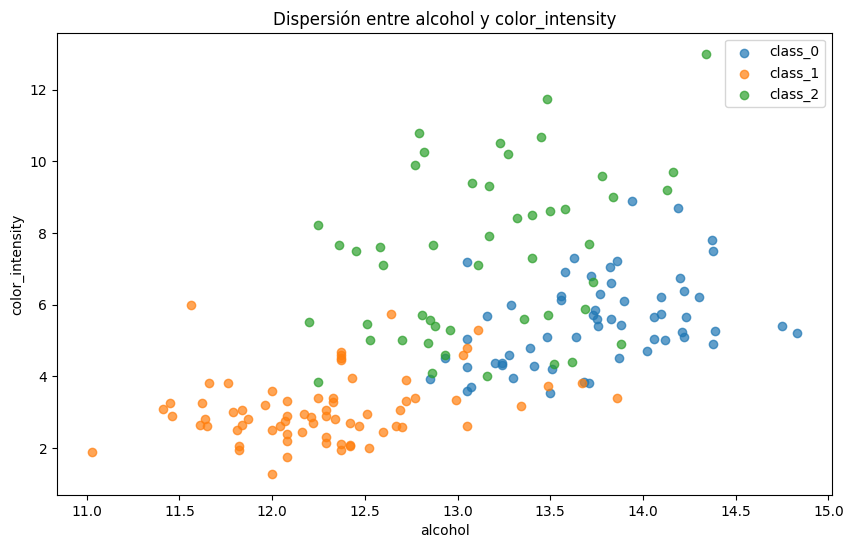

In [6]:
# Scatter plot con dos variables
columna_x = "alcohol"
columna_y = "color_intensity"

for clase in sorted(df["target"].unique()):
    subset = df[df["target"] == clase]
    plt.scatter(subset[columna_x], subset[columna_y], label=wine.target_names[clase], alpha=0.7)

plt.title("Dispersión entre alcohol y color_intensity")
plt.xlabel(columna_x)
plt.ylabel(columna_y)
plt.legend()
plt.show()



Este gráfico permite ver si hay separación natural entre clases.
Si la separación fuera casi recta, LDA tendría una ventaja clara.
Si la separación fuera más curva o irregular, QDA podría captarla mejor.


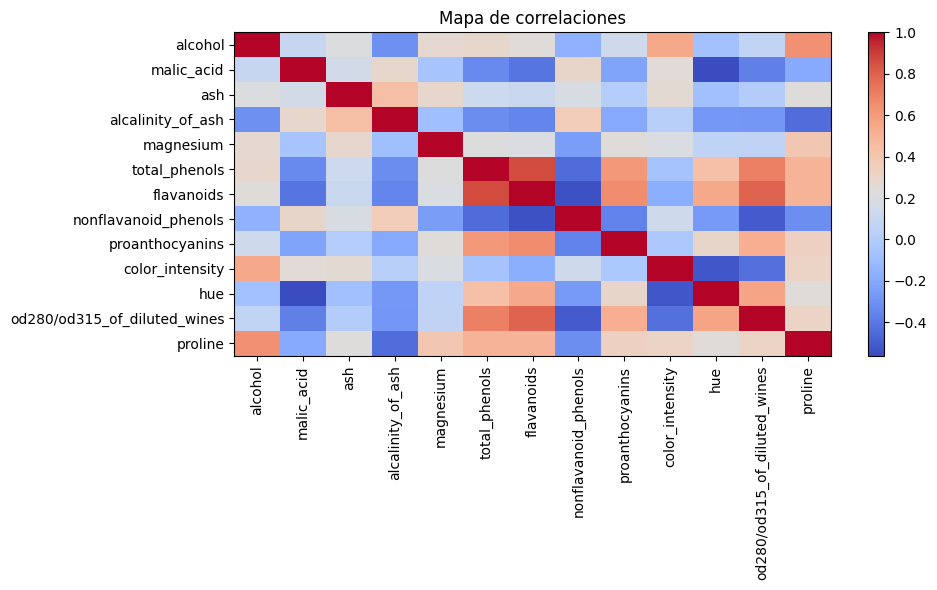

In [7]:
# Mapa de correlaciones
matriz_corr = df.drop(columns=["target"]).corr()

plt.imshow(matriz_corr, cmap="coolwarm", aspect="auto")
plt.colorbar()
plt.xticks(range(len(matriz_corr.columns)), matriz_corr.columns, rotation=90)
plt.yticks(range(len(matriz_corr.columns)), matriz_corr.columns)
plt.title("Mapa de correlaciones")
plt.tight_layout()
plt.show()



Aquí se observa que algunas variables están correlacionadas.
Eso no impide usar LDA o QDA, pero sí influye en cómo se comportan sus matrices de covarianza.


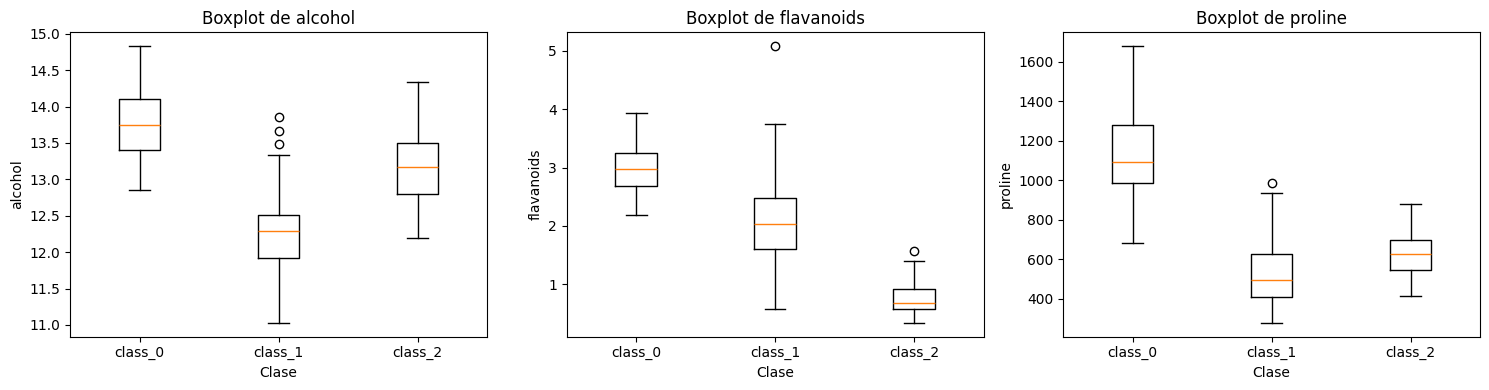

In [8]:
# Boxplots de algunas variables
variables_box = ["alcohol", "flavanoids", "proline"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for i, var in enumerate(variables_box):
    datos_por_clase = [df[df["target"] == clase][var] for clase in sorted(df["target"].unique())]
    axes[i].boxplot(datos_por_clase, tick_labels=wine.target_names)
    axes[i].set_title(f"Boxplot de {var}")
    axes[i].set_xlabel("Clase")
    axes[i].set_ylabel(var)

plt.tight_layout()
plt.show()



Los boxplots ayudan a ver diferencias de nivel y dispersión entre clases.
Si una variable cambia bastante entre grupos, tiene buena capacidad para discriminar.


## 5. Preparación de los datos

- separamos entrenamiento y prueba
- estandarizamos las variables


In [9]:
# Separar entrenamiento y prueba
X_entrenamiento, X_prueba, y_entrenamiento, y_prueba = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Forma de X_entrenamiento:", X_entrenamiento.shape)
print("Forma de X_prueba:", X_prueba.shape)
print("Forma de y_entrenamiento:", y_entrenamiento.shape)
print("Forma de y_prueba:", y_prueba.shape)

# Estandarizar
escalador = StandardScaler()
X_entrenamiento_esc = escalador.fit_transform(X_entrenamiento)
X_prueba_esc = escalador.transform(X_prueba)


Forma de X_entrenamiento: (124, 13)
Forma de X_prueba: (54, 13)
Forma de y_entrenamiento: (124,)
Forma de y_prueba: (54,)


## 6. Implementación de LDA

Entrenamos un modelo LinearDiscriminantAnalysis.
Luego calculamos:

- matriz de confusión
- accuracy
- precisión
- recall
- F1-score


In [10]:
# Crear y entrenar modelo LDA
modelo_lda = LinearDiscriminantAnalysis()
modelo_lda.fit(X_entrenamiento_esc, y_entrenamiento)

# Predicciones
pred_lda = modelo_lda.predict(X_prueba_esc)

# Métricas
accuracy_lda = accuracy_score(y_prueba, pred_lda)
precision_lda = precision_score(y_prueba, pred_lda, average="weighted")
recall_lda = recall_score(y_prueba, pred_lda, average="weighted")
f1_lda = f1_score(y_prueba, pred_lda, average="weighted")

print("Resultados LDA")
print("Accuracy:", round(accuracy_lda, 4))
print("Precisión:", round(precision_lda, 4))
print("Recall:", round(recall_lda, 4))
print("F1-score:", round(f1_lda, 4))


Resultados LDA
Accuracy: 0.9815
Precisión: 0.9825
Recall: 0.9815
F1-score: 0.9815


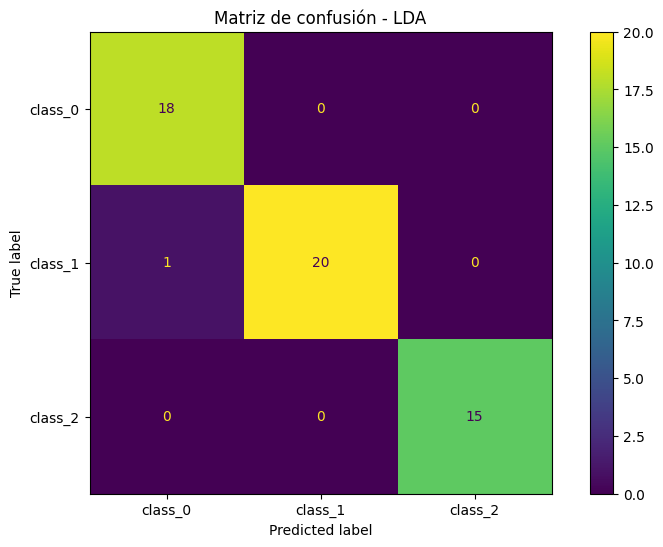

Reporte de clasificación LDA:

              precision    recall  f1-score   support

     class_0       0.95      1.00      0.97        18
     class_1       1.00      0.95      0.98        21
     class_2       1.00      1.00      1.00        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



In [11]:
# Matriz de confusión LDA
cm_lda = confusion_matrix(y_prueba, pred_lda)
disp_lda = ConfusionMatrixDisplay(confusion_matrix=cm_lda, display_labels=wine.target_names)
disp_lda.plot()
plt.title("Matriz de confusión - LDA")
plt.show()

print("Reporte de clasificación LDA:\n")
print(classification_report(y_prueba, pred_lda, target_names=wine.target_names))



LDA asume que las clases comparten una misma matriz de covarianza.
Eso hace que el modelo sea más simple y estable, y por eso muchas veces funciona muy bien cuando los grupos no son demasiado distintos en su dispersión.


## 7. Implementación de QDA

Ahora con QuadraticDiscriminantAnalysis.



In [12]:
# Crear y entrenar modelo QDA
modelo_qda = QuadraticDiscriminantAnalysis()
modelo_qda.fit(X_entrenamiento_esc, y_entrenamiento)

# Predicciones
pred_qda = modelo_qda.predict(X_prueba_esc)

# Métricas
accuracy_qda = accuracy_score(y_prueba, pred_qda)
precision_qda = precision_score(y_prueba, pred_qda, average="weighted")
recall_qda = recall_score(y_prueba, pred_qda, average="weighted")
f1_qda = f1_score(y_prueba, pred_qda, average="weighted")

print("Resultados QDA")
print("Accuracy:", round(accuracy_qda, 4))
print("Precisión:", round(precision_qda, 4))
print("Recall:", round(recall_qda, 4))
print("F1-score:", round(f1_qda, 4))


Resultados QDA
Accuracy: 1.0
Precisión: 1.0
Recall: 1.0
F1-score: 1.0


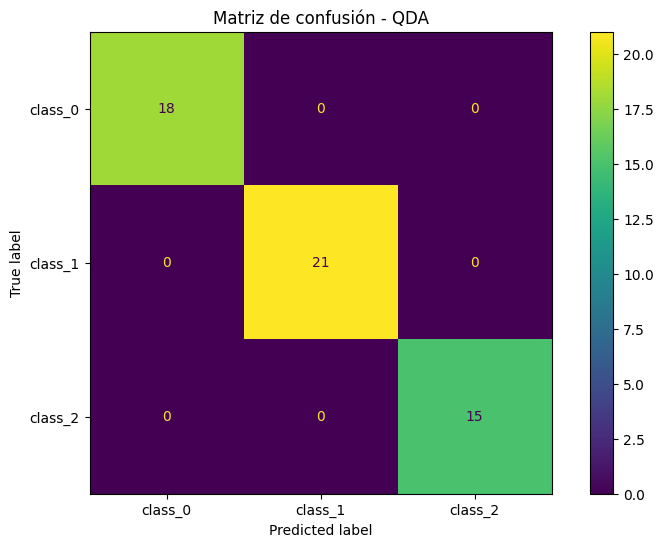

Reporte de clasificación QDA:

              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        15

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



In [13]:
# Matriz de confusión QDA
cm_qda = confusion_matrix(y_prueba, pred_qda)
disp_qda = ConfusionMatrixDisplay(confusion_matrix=cm_qda, display_labels=wine.target_names)
disp_qda.plot()
plt.title("Matriz de confusión - QDA")
plt.show()

print("Reporte de clasificación QDA:\n")
print(classification_report(y_prueba, pred_qda, target_names=wine.target_names))



QDA es más flexible que LDA porque no obliga a que todas las clases tengan la misma covarianza.
Eso puede ser una ventaja si los grupos realmente tienen formas distintas, aunque también puede volver al modelo más sensible cuando la muestra no es grande.


## 8. Comparación de modelos

Aquí juntamos ambas métricas para ver con claridad cuál rindió mejor en este dataset.


In [14]:
comparacion = pd.DataFrame({
    "Modelo": ["LDA", "QDA"],
    "Accuracy": [accuracy_lda, accuracy_qda],
    "Precisión": [precision_lda, precision_qda],
    "Recall": [recall_lda, recall_qda],
    "F1-score": [f1_lda, f1_qda]
})

display(comparacion)


,Modelo,Accuracy,Precisión,Recall,F1-score
0,LDA,0.981481,0.982456,0.981481,0.981506
1,QDA,1.000000,1.000000,1.000000,1.000000


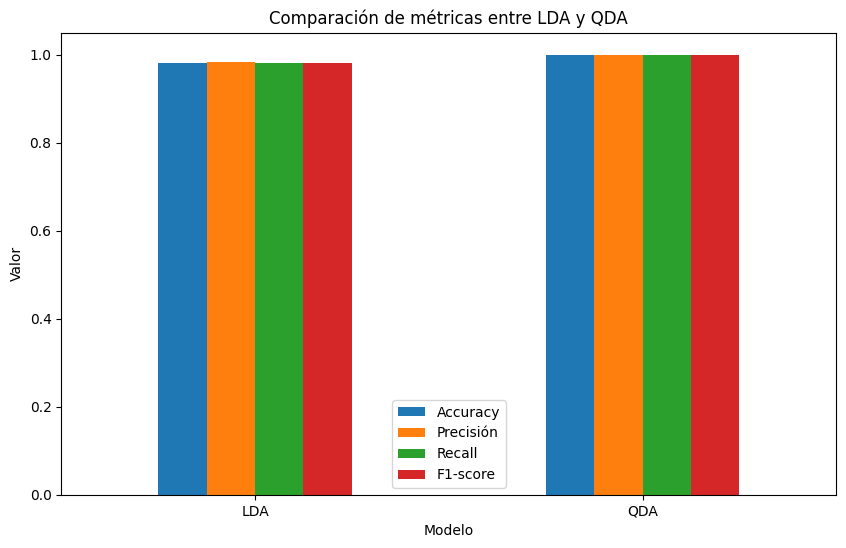

In [15]:
# Gráfico comparativo
comparacion_graf = comparacion.set_index("Modelo")
comparacion_graf.plot(kind="bar")
plt.title("Comparación de métricas entre LDA y QDA")
plt.ylabel("Valor")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.show()



Aquí se ve si la mayor flexibilidad de QDA realmente aportó algo o si LDA, por ser más simple, fue suficiente.
En muchos conjuntos de datos bien separados, LDA puede competir muy bien aunque tenga un supuesto más restrictivo.


## 9. Fronteras de decisión

Para esta parte usamos solo dos variables:
- alcohol
- color_intensity

Esto permite dibujar la frontera de decisión de ambos modelos.


In [16]:
# Seleccionar dos variables para visualizar fronteras
X_dos = df[["alcohol", "color_intensity"]]
y_dos = df["target"]

X_entrenamiento_2, X_prueba_2, y_entrenamiento_2, y_prueba_2 = train_test_split(
    X_dos, y_dos,
    test_size=0.30,
    random_state=42,
    stratify=y_dos
)

# Estandarizar
escalador_2 = StandardScaler()
X_entrenamiento_2_esc = escalador_2.fit_transform(X_entrenamiento_2)
X_prueba_2_esc = escalador_2.transform(X_prueba_2)

# Entrenar modelos
lda_2 = LinearDiscriminantAnalysis()
qda_2 = QuadraticDiscriminantAnalysis()

lda_2.fit(X_entrenamiento_2_esc, y_entrenamiento_2)
qda_2.fit(X_entrenamiento_2_esc, y_entrenamiento_2)


QuadraticDiscriminantAnalysis()

In [17]:
# Crear malla para las fronteras
x_min, x_max = X_entrenamiento_2_esc[:, 0].min() - 1, X_entrenamiento_2_esc[:, 0].max() + 1
y_min, y_max = X_entrenamiento_2_esc[:, 1].min() - 1, X_entrenamiento_2_esc[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

malla = np.c_[xx.ravel(), yy.ravel()]

pred_malla_lda = lda_2.predict(malla).reshape(xx.shape)
pred_malla_qda = qda_2.predict(malla).reshape(xx.shape)


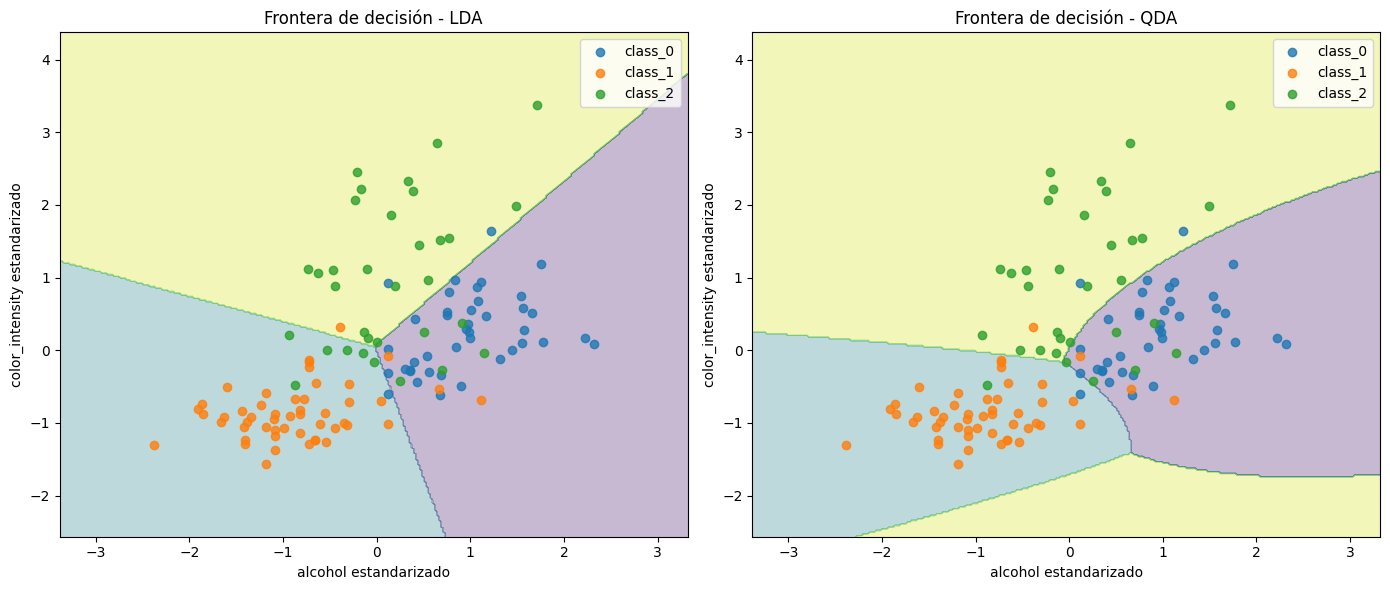

In [18]:
# Gráfico de fronteras de decisión
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# LDA
axes[0].contourf(xx, yy, pred_malla_lda, alpha=0.3)
for clase in np.unique(y_entrenamiento_2):
    puntos = X_entrenamiento_2_esc[y_entrenamiento_2 == clase]
    axes[0].scatter(puntos[:, 0], puntos[:, 1], label=wine.target_names[clase], alpha=0.8)
axes[0].set_title("Frontera de decisión - LDA")
axes[0].set_xlabel("alcohol estandarizado")
axes[0].set_ylabel("color_intensity estandarizado")
axes[0].legend()

# QDA
axes[1].contourf(xx, yy, pred_malla_qda, alpha=0.3)
for clase in np.unique(y_entrenamiento_2):
    puntos = X_entrenamiento_2_esc[y_entrenamiento_2 == clase]
    axes[1].scatter(puntos[:, 0], puntos[:, 1], label=wine.target_names[clase], alpha=0.8)
axes[1].set_title("Frontera de decisión - QDA")
axes[1].set_xlabel("alcohol estandarizado")
axes[1].set_ylabel("color_intensity estandarizado")
axes[1].legend()

plt.tight_layout()
plt.show()


### Interpretación de las fronteras

La frontera de **LDA** se ve más recta porque el modelo supone una covarianza común para todas las clases.  
La frontera de **QDA** puede curvarse porque cada clase tiene su propia covarianza.  
Eso hace a QDA más flexible, aunque no siempre esa flexibilidad mejora el resultado final.


## Conclusiones

1. LDA y QDA son clasificadores probabilísticos que parten de la idea de modelar cada clase con una distribución gaussiana.
2. LDA es más restrictivo, porque obliga a compartir una misma matriz de covarianza entre clases, pero esa misma restricción lo vuelve más estable.
3. QDA es más flexible, porque permite una matriz de covarianza distinta por clase, y eso puede ayudar cuando los grupos tienen formas realmente diferentes.
4. En este dataset, la comparación muestra que la flexibilidad extra de QDA no siempre garantiza una mejora clara, así que el mejor modelo depende del comportamiento real de los datos.
5. Las fronteras de decisión permiten ver la diferencia central entre ambos métodos: LDA separa con líneas rectas, mientras QDA puede separar con curvas.
6. En términos prácticos, LDA suele ser una muy buena opción base cuando el conjunto de datos no es enorme y la estructura entre clases no es demasiado compleja.
7. QDA conviene más cuando hay evidencia de que las clases tienen dispersión distinta y cuando se cuenta con suficientes datos para estimar bien una covarianza por clase.
